<a href="https://colab.research.google.com/github/JAHNAVI-BOOPATHY/deeplearning/blob/main/Assignment_4_Netflix_Review_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv('/content/netflix_reviews.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.shape

(155850, 8)

In [ ]:
df.columns

Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155850 entries, 0 to 155849
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              155850 non-null  object
 1   userName              155848 non-null  object
 2   content               155843 non-null  object
 3   score                 155850 non-null  int64 
 4   thumbsUpCount         155850 non-null  int64 
 5   reviewCreatedVersion  127236 non-null  object
 6   at                    155850 non-null  object
 7   appVersion            127236 non-null  object
dtypes: int64(2), object(6)
memory usage: 9.5+ MB


In [ ]:
df.isnull().sum()

,0
reviewId,0
userName,2
content,7
score,0
thumbsUpCount,0
reviewCreatedVersion,28614
at,0
appVersion,28614


In [ ]:
clean_df = df.copy()

print("Backup created successfully!")

Backup created successfully!


In [ ]:
clean_df.duplicated().sum()

np.int64(287)

In [ ]:
clean_df = clean_df.drop_duplicates()

print("Duplicates removed.")
print("New dataset size:", clean_df.shape)

Duplicates removed.
New dataset size: (155563, 8)


In [ ]:
clean_df['content'].isnull().sum()

np.int64(7)

clean_df = clean_df.dropna(subset=['content'])

print("Reviews without text removed.")
print("Current dataset size:", clean_df.shape)

In [ ]:
clean_df['score'].value_counts().sort_index()

,count
score,
1,60704
2,13234
3,14436
4,16670
5,50519


In [ ]:
clean_df = clean_df[clean_df['score'].between(1, 5)]

print("Invalid ratings removed.")
print("Current dataset size:", clean_df.shape)

Invalid ratings removed.
Current dataset size: (155563, 8)


In [ ]:
clean_df['content'] = clean_df['content'].astype(str).str.strip()

In [ ]:
print("Final cleaned dataset shape:", clean_df.shape)
clean_df.head()

Final cleaned dataset shape: (155563, 8)


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,2b5316f6-35c7-4768-b7f6-ca8964c48d16,anshu pathak,good,5,0,9.78.0 build 7 64348,2026-08-13 09:06:11,9.78.0 build 7 64348
1,c8b028d8-031b-4dd1-a7ec-335fe07f6a7d,Hassan YT,best,5,0,9.78.0 build 7 64348,2026-08-13 09:04:24,9.78.0 build 7 64348
2,ced082f5-6d8a-4621-885c-d090b1268626,Shamim Bano,kuchh series nhi dikh ri h,1,0,NaN,2026-08-13 09:01:54,NaN
3,e092398d-4eac-48b4-a34d-ec655e1d51b8,Harendra Kumar,ी रियली लव्ड it,4,0,9.78.0 build 7 64348,2026-08-13 08:59:14,9.78.0 build 7 64348
4,7eb12e13-8c4d-4f19-bea3-122f5f974f6f,Chris Sydwell,very fun and lovely.,5,0,NaN,2026-08-13 08:54:32,NaN


In [ ]:
rating_counts = clean_df['score'].value_counts().sort_index()
print(rating_counts)

score
1    60704
2    13234
3    14436
4    16670
5    50519
Name: count, dtype: int64


In [ ]:
rating_percent = (rating_counts / len(clean_df)) * 100

print(rating_percent.round(2))

score
1    39.02
2     8.51
3     9.28
4    10.72
5    32.47
Name: count, dtype: float64


In [ ]:
average_rating = clean_df['score'].mean()
print("Average Rating:", round(average_rating, 2))

Average Rating: 2.89


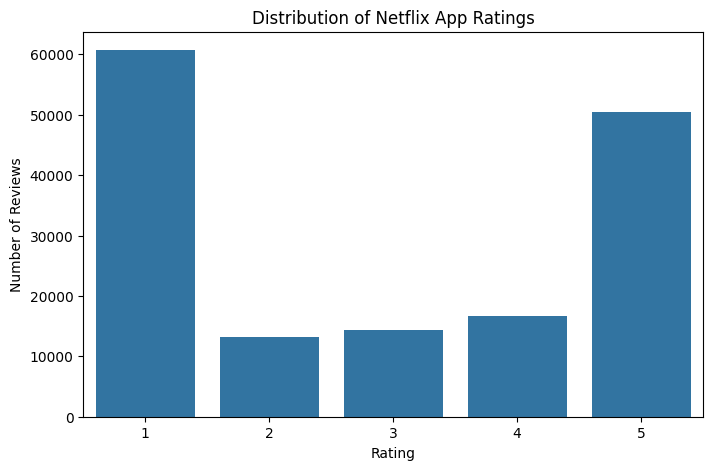

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=clean_df, x='score')

plt.title('Distribution of Netflix App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

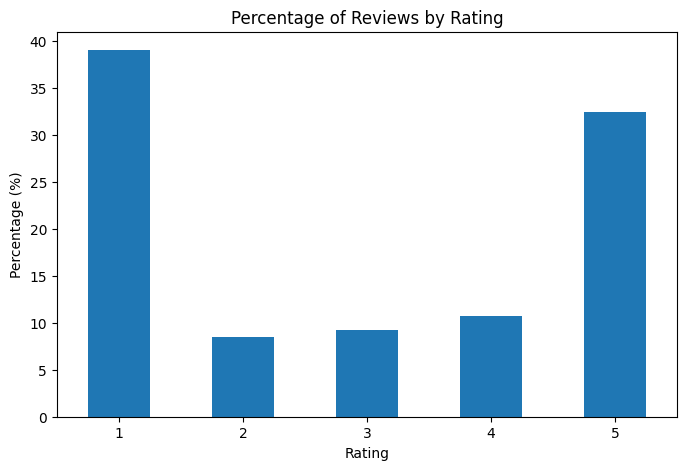

In [ ]:
plt.figure(figsize=(8, 5))

rating_percent.plot(kind='bar')

plt.title('Percentage of Reviews by Rating')
plt.xlabel('Rating')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.show()

In [ ]:
def rating_group(score):
    if score <= 2:
        return 'Low'
    elif score == 3:
        return 'Neutral'
    else:
        return 'High'

clean_df['rating_group'] = clean_df['score'].apply(rating_group)

In [ ]:
clean_df['rating_group'].value_counts()

,count
rating_group,
Low,73938
High,67189
Neutral,14436


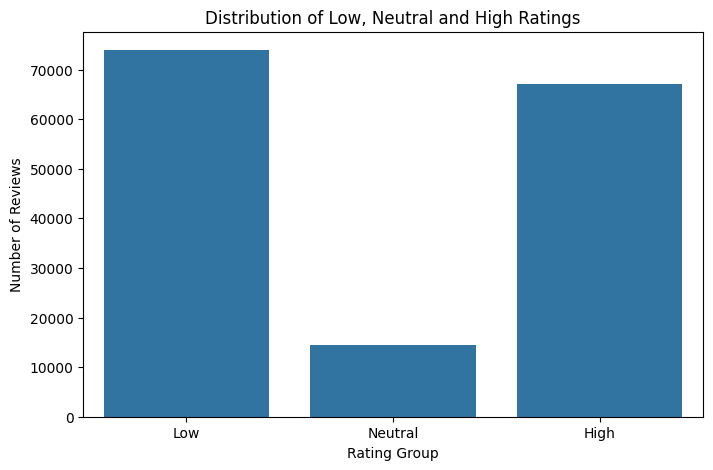

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x='rating_group',
    order=['Low', 'Neutral', 'High']
)

plt.title('Distribution of Low, Neutral and High Ratings')
plt.xlabel('Rating Group')
plt.ylabel('Number of Reviews')

plt.show()

In [ ]:
clean_df[['score', 'rating_group', 'content']].head(10)

,score,rating_group,content
0,5,High,good
1,5,High,best
2,1,Low,kuchh series nhi dikh ri h
3,4,High,ी रियली लव्ड it
4,5,High,very fun and lovely.
5,1,Low,Did not get help
6,1,Low,it is not playing my movies if again and agin ...
7,5,High,"Nice, because I can watch my favorite movies a..."
8,5,High,super
9,5,High,Very well directed. This movie shows how someo...


In [ ]:
clean_df['review_length'] = clean_df['content'].str.len()

clean_df['review_length'].describe()

,review_length
count,155563.000000
mean,138.319845
std,115.890199
min,1.000000
25%,60.000000
50%,109.000000
75%,179.000000
max,1752.000000


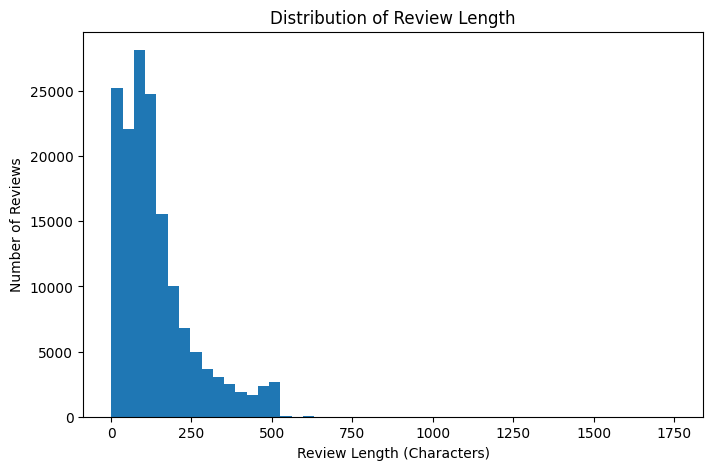

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    clean_df['review_length'],
    bins=50
)

plt.title('Distribution of Review Length')
plt.xlabel('Review Length (Characters)')
plt.ylabel('Number of Reviews')

plt.show()

In [ ]:
!pip install nltk

In [ ]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

In [ ]:
clean_df['cleaned_content'] = clean_df['content'].apply(clean_text)

In [ ]:
clean_df[['content', 'cleaned_content']].head(10)

,content,cleaned_content
0,good,good
1,best,best
2,kuchh series nhi dikh ri h,kuchh series nhi dikh ri h
3,ी रियली लव्ड it,
4,very fun and lovely.,fun lovely
5,Did not get help,get help
6,it is not playing my movies if again and agin ...,playing movies agin shows netflix responding
7,"Nice, because I can watch my favorite movies a...",nice watch favorite movies animes
8,super,super
9,Very well directed. This movie shows how someo...,well directed movie shows someone honestly sna...


In [ ]:
all_reviews = ' '.join(clean_df['cleaned_content'])

print("Text combined successfully!")

Text combined successfully!


In [ ]:
from collections import Counter

word_counts = Counter(all_reviews.split())

print(word_counts.most_common(20))

[('netflix', 59887), ('app', 59507), ('movies', 31336), ('watch', 30082), ('good', 24527), ('shows', 22747), ('like', 19479), ('cant', 17690), ('love', 17087), ('please', 14851), ('dont', 14319), ('great', 13318), ('even', 13137), ('im', 12753), ('phone', 12198), ('movie', 11478), ('time', 11356), ('tv', 11322), ('get', 10815), ('series', 10533)]


In [ ]:
top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=['Word', 'Frequency']
)

top_words

,Word,Frequency
0,netflix,59887
1,app,59507
2,movies,31336
3,watch,30082
4,good,24527
5,shows,22747
6,like,19479
7,cant,17690
8,love,17087
9,please,14851


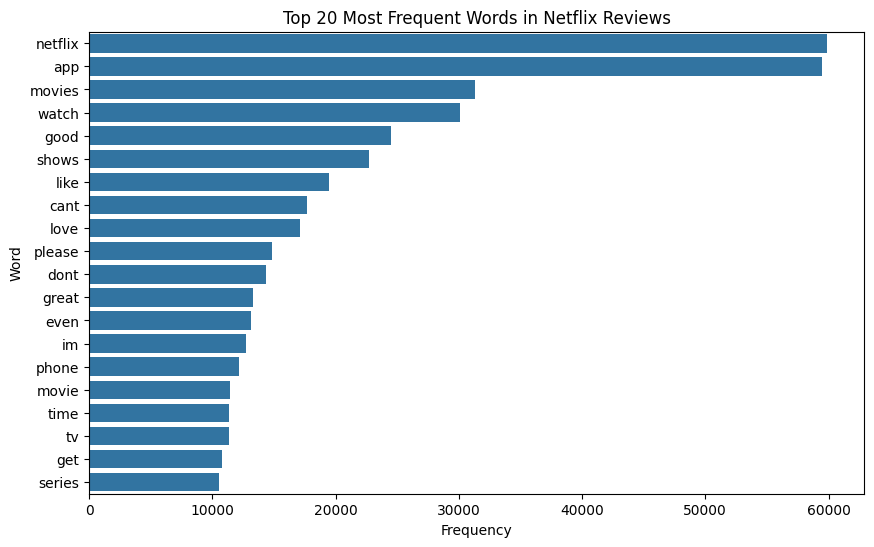

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_words,
    x='Frequency',
    y='Word'
)

plt.title('Top 20 Most Frequent Words in Netflix Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.show()

In [ ]:
!pip install wordcloud

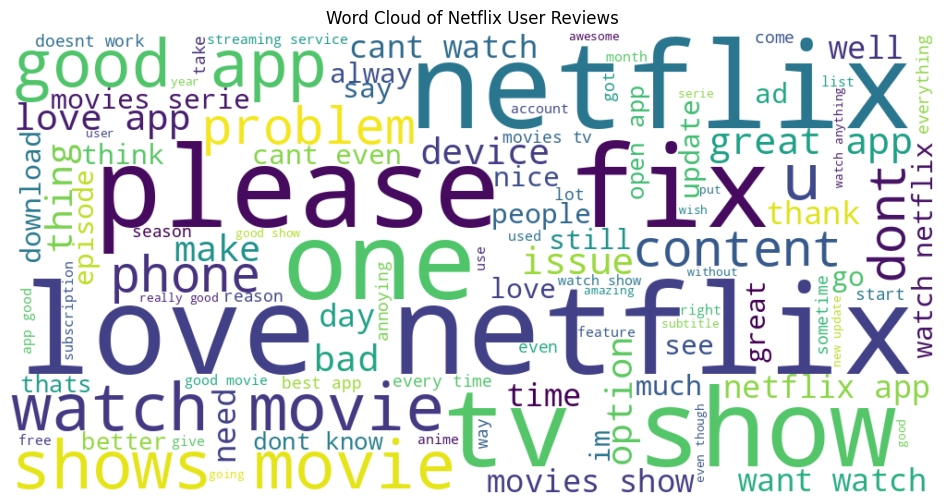

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(all_reviews)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Netflix User Reviews')

plt.show()

In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob

print("TextBlob imported successfully!")

TextBlob imported successfully!


In [ ]:
test_review = clean_df['content'].iloc[0]

print("Review:")
print(test_review)

print("\nPolarity:")
print(TextBlob(test_review).sentiment.polarity)

Review:
good

Polarity:
0.7


In [ ]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

In [ ]:
print(get_sentiment("I love this app"))
print(get_sentiment("This app is terrible"))
print(get_sentiment("The app is okay"))

Positive
Negative
Positive


In [ ]:
clean_df['sentiment'] = clean_df['content'].apply(get_sentiment)

In [ ]:
print("Sentiment analysis completed!")

Sentiment analysis completed!


In [ ]:
sentiment_counts = clean_df['sentiment'].value_counts()

print(sentiment_counts)

sentiment
Positive    90853
Negative    35358
Neutral     29352
Name: count, dtype: int64


In [ ]:
sentiment_percent = (
    clean_df['sentiment'].value_counts(normalize=True) * 100
)

print(sentiment_percent.round(2))

sentiment
Positive    58.40
Negative    22.73
Neutral     18.87
Name: proportion, dtype: float64


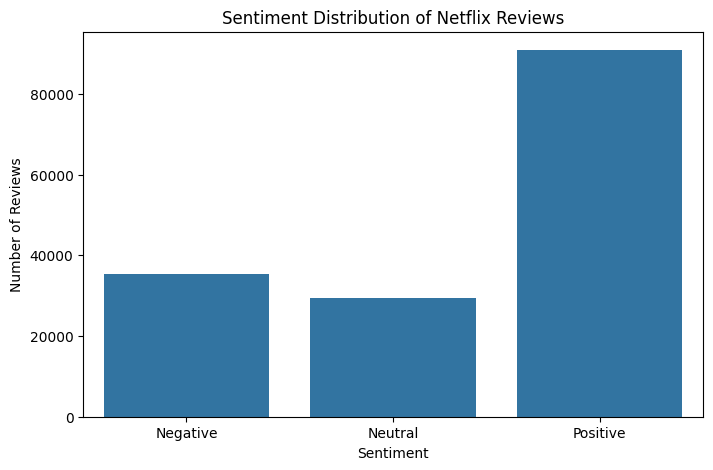

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x='sentiment',
    order=['Negative', 'Neutral', 'Positive']
)

plt.title('Sentiment Distribution of Netflix Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [ ]:
rating_sentiment = pd.crosstab(
    clean_df['score'],
    clean_df['sentiment']
)

rating_sentiment

sentiment,Negative,Neutral,Positive
score,,,
1,24326,16264,20114
2,4257,2709,6268
3,3267,2487,8682
4,1753,1951,12966
5,1755,5941,42823


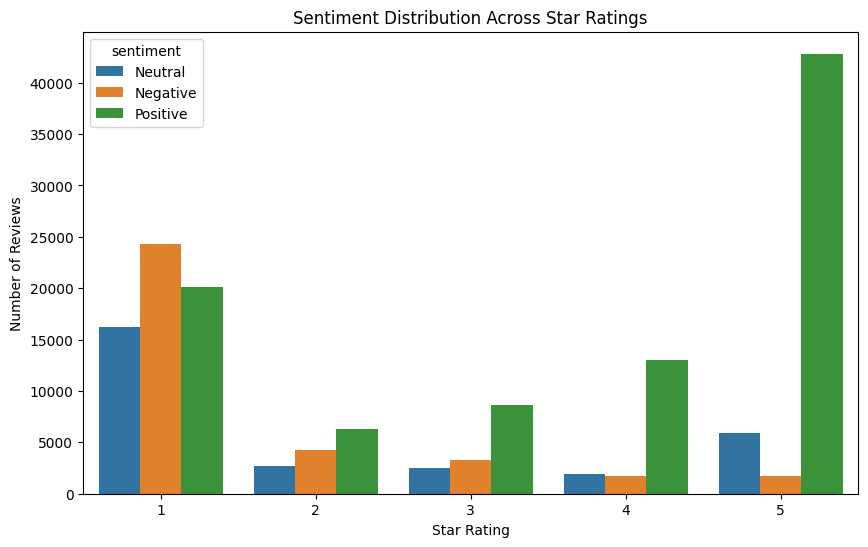

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=clean_df,
    x='score',
    hue='sentiment'
)

plt.title('Sentiment Distribution Across Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')

plt.show()

In [ ]:
low_reviews = clean_df[clean_df['rating_group'] == 'Low']
high_reviews = clean_df[clean_df['rating_group'] == 'High']

print("Low-rating reviews:", len(low_reviews))
print("High-rating reviews:", len(high_reviews))

Low-rating reviews: 73938
High-rating reviews: 67189


In [ ]:
low_text = ' '.join(low_reviews['cleaned_content'])

print("Low-rating review text prepared!")

Low-rating review text prepared!


In [ ]:
high_text = ' '.join(high_reviews['cleaned_content'])

print("High-rating review text prepared!")

High-rating review text prepared!


In [ ]:
low_word_counts = Counter(low_text.split())

low_top_words = pd.DataFrame(
    low_word_counts.most_common(30),
    columns=['Word', 'Frequency']
)

low_top_words

,Word,Frequency
0,netflix,31089
1,app,30395
2,cant,13216
3,watch,12846
4,even,9698
5,movies,8618
6,phone,8598
7,dont,8566
8,shows,7988
9,im,7846


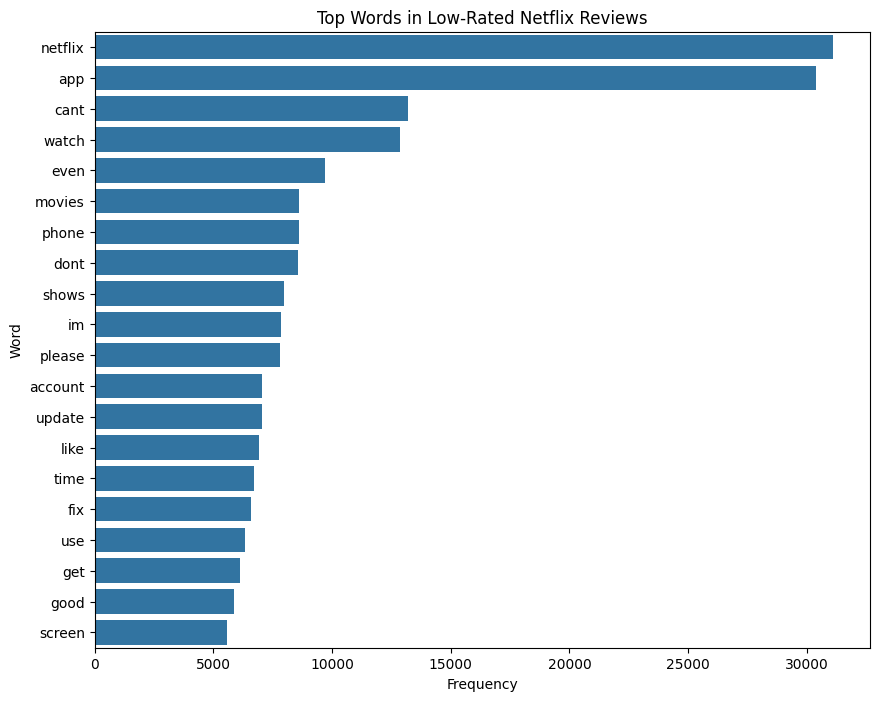

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=low_top_words.head(20),
    x='Frequency',
    y='Word'
)

plt.title('Top Words in Low-Rated Netflix Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.show()

In [ ]:
high_word_counts = Counter(high_text.split())

high_top_words = pd.DataFrame(
    high_word_counts.most_common(30),
    columns=['Word', 'Frequency']
)

high_top_words

,Word,Frequency
0,app,23285
1,netflix,23280
2,movies,19114
3,good,15827
4,love,14724
5,watch,14376
6,shows,12073
7,great,10268
8,like,9862
9,best,7351


In [ ]:
high_word_counts = Counter(high_text.split())

high_top_words = pd.DataFrame(
    high_word_counts.most_common(30),
    columns=['Word', 'Frequency']
)

high_top_words

,Word,Frequency
0,app,23285
1,netflix,23280
2,movies,19114
3,good,15827
4,love,14724
5,watch,14376
6,shows,12073
7,great,10268
8,like,9862
9,best,7351


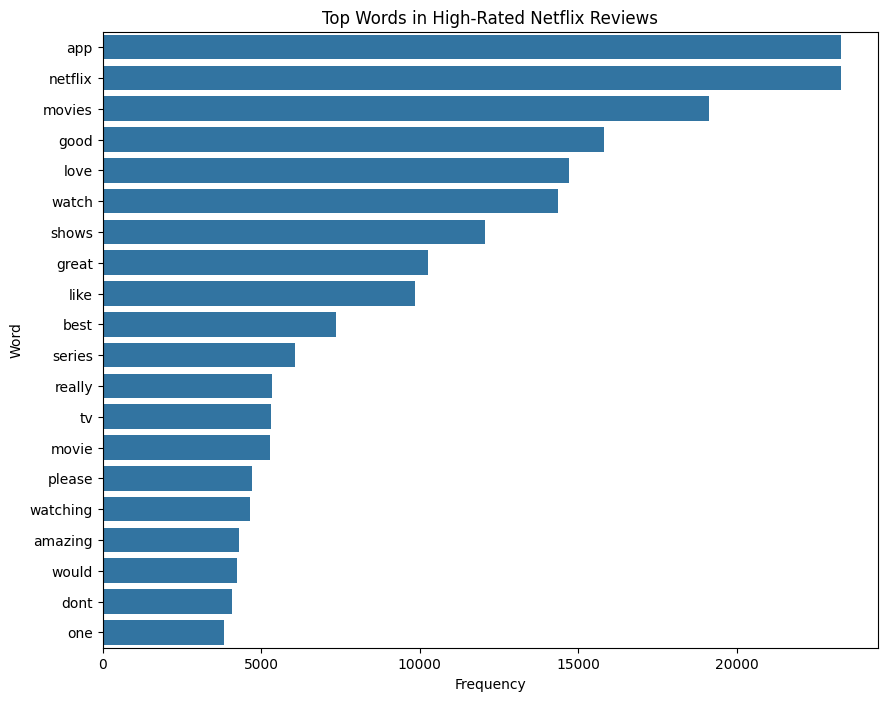

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=high_top_words.head(20),
    x='Frequency',
    y='Word'
)

plt.title('Top Words in High-Rated Netflix Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.show()

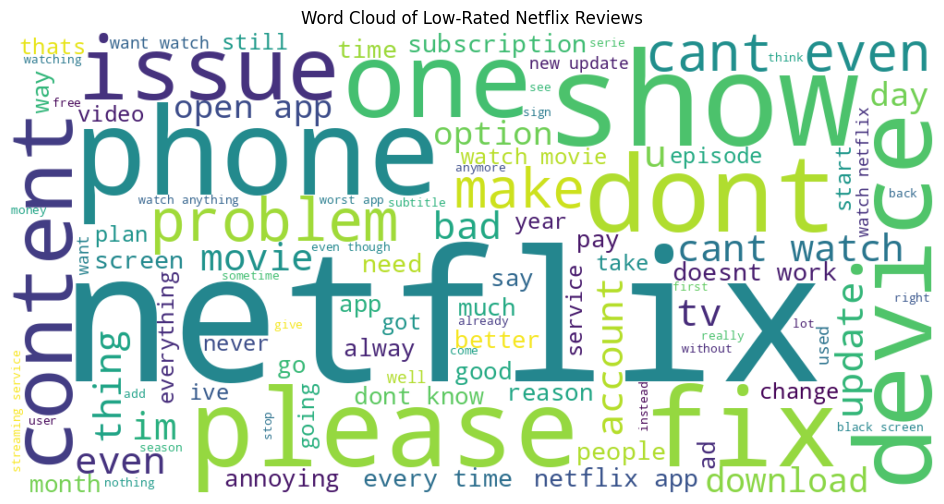

In [ ]:
low_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(low_text)

plt.figure(figsize=(12, 6))
plt.imshow(low_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Low-Rated Netflix Reviews')

plt.show()

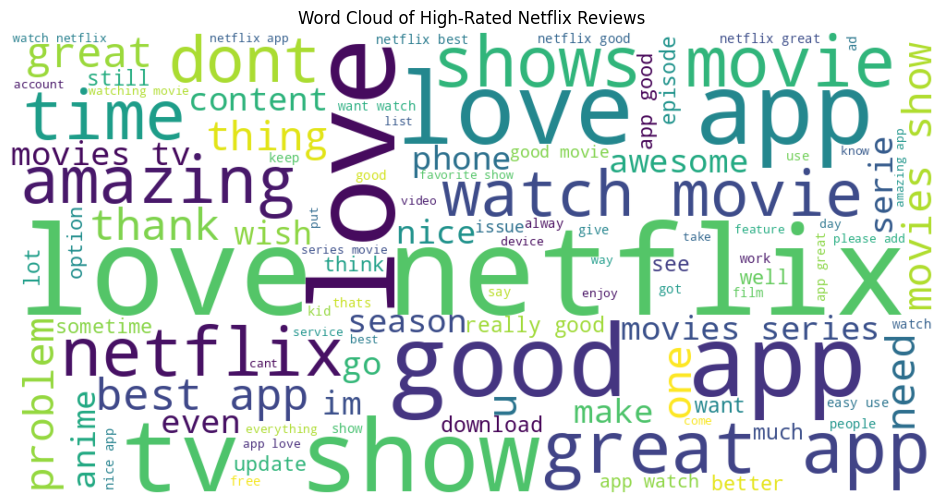

In [ ]:
high_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(high_text)

plt.figure(figsize=(12, 6))
plt.imshow(high_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of High-Rated Netflix Reviews')

plt.show()

In [ ]:
low_total = sum(low_word_counts.values())
high_total = sum(high_word_counts.values())

low_frequency = {
    word: count / low_total
    for word, count in low_word_counts.items()
}

high_frequency = {
    word: count / high_total
    for word, count in high_word_counts.items()
}

In [ ]:
low_association = []

for word, freq in low_frequency.items():
    if word in high_frequency:
        score = freq / high_frequency[word]
    else:
        score = freq * 100

    low_association.append((word, score))

low_association_df = pd.DataFrame(
    low_association,
    columns=['Word', 'Low_Association_Score']
)

low_association_df = low_association_df.sort_values(
    'Low_Association_Score',
    ascending=False
)

low_association_df.head(30)

,Word,Low_Association_Score
4444,unwatchable,80.435915
1212,biased,65.811203
1177,unsubscribed,63.983115
1472,bloatware,59.108211
5046,sbr,47.530314
3452,unsubscribing,45.092862
4037,stealing,44.483499
1223,jackson,42.046047
3067,straw,38.999232
1650,cheating,37.171143


In [ ]:
high_association = []

for word, freq in high_frequency.items():
    if word in low_frequency:
        score = freq / low_frequency[word]
    else:
        score = freq * 100

    high_association.append((word, score))

high_association_df = pd.DataFrame(
    high_association,
    columns=['Word', 'High_Association_Score']
)

high_association_df = high_association_df.sort_values(
    'High_Association_Score',
    ascending=False
)

high_association_df.head(30)

,Word,High_Association_Score
1088,highquality,119.797232
628,topnotch,64.001261
2567,addicted,51.966836
373,entertained,50.052268
8407,danger,44.308565
6976,addicting,42.667507
683,toptier,42.667507
1074,bingewatch,42.667507
238,relaxing,41.436714
7816,verity,41.026449


In [ ]:
low_association_df.head(30)

,Word,Low_Association_Score
4444,unwatchable,80.435915
1212,biased,65.811203
1177,unsubscribed,63.983115
1472,bloatware,59.108211
5046,sbr,47.530314
3452,unsubscribing,45.092862
4037,stealing,44.483499
1223,jackson,42.046047
3067,straw,38.999232
1650,cheating,37.171143


In [ ]:
high_association_df.head(30)

,Word,High_Association_Score
1088,highquality,119.797232
628,topnotch,64.001261
2567,addicted,51.966836
373,entertained,50.052268
8407,danger,44.308565
6976,addicting,42.667507
683,toptier,42.667507
1074,bingewatch,42.667507
238,relaxing,41.436714
7816,verity,41.026449


In [ ]:
# Minimum number of occurrences required
MIN_COUNT = 50

# Keep only reasonably frequent words
low_common = {
    word: count
    for word, count in low_word_counts.items()
    if count >= MIN_COUNT
}

high_common = {
    word: count
    for word, count in high_word_counts.items()
    if count >= MIN_COUNT
}

# Calculate relative frequencies
low_total = sum(low_common.values())
high_total = sum(high_common.values())

# Words associated with LOW ratings
low_association = []

for word, count in low_common.items():
    low_rate = count / low_total
    high_rate = high_common.get(word, 0) / high_total

    if high_rate > 0:
        association = low_rate / high_rate
    else:
        association = 0

    low_association.append((word, count, association))

low_association_df = pd.DataFrame(
    low_association,
    columns=['Word', 'Low_Frequency', 'Association_Score']
)

low_association_df = low_association_df[
    low_association_df['Association_Score'] > 1
].sort_values(
    'Association_Score',
    ascending=False
)

# Words associated with HIGH ratings
high_association = []

for word, count in high_common.items():
    high_rate = count / high_total
    low_rate = low_common.get(word, 0) / low_total

    if low_rate > 0:
        association = high_rate / low_rate
    else:
        association = 0

    high_association.append((word, count, association))

high_association_df = pd.DataFrame(
    high_association,
    columns=['Word', 'High_Frequency', 'Association_Score']
)

high_association_df = high_association_df[
    high_association_df['Association_Score'] > 1
].sort_values(
    'Association_Score',
    ascending=False
)

print("🔴 Words associated with LOW ratings:")
display(low_association_df.head(30))

print("\n🟢 Words associated with HIGH ratings:")
display(high_association_df.head(30))

🔴 Words associated with LOW ratings:


,Word,Low_Frequency,Association_Score
35,household,2000,17.239546
60,worst,2825,15.332022
726,sharing,1021,9.350837
148,waste,1422,8.962339
219,stupid,1042,8.366611
628,uninstalled,1084,8.360272
317,uninstall,1864,7.694179
627,cancelled,889,7.662978
447,cancel,1915,7.533334
1120,uninstalling,649,7.458977



🟢 Words associated with HIGH ratings:


,Word,High_Frequency,Association_Score
149,excellent,1414,41.592658
38,amazing,4299,32.168281
117,awesome,2373,27.920616
31,love,14724,19.518324
1,best,7351,15.996524
94,variety,1023,14.917122
2,fun,977,14.494124
199,entertaining,428,13.522135
170,wide,401,13.414345
4,nice,3470,13.039738


In [ ]:
# Define our business themes using keywords from the reviews

themes = {
    'Technical & Performance Issues': [
        'crashing', 'crash', 'error', 'cache', 'unable', 'opening'
    ],

    'Installation / App Problems': [
        'uninstall', 'uninstalled', 'uninstalling', 'reinstalled', 'reinstalling'
    ],

    'Cancellation Issues': [
        'cancel', 'cancelled', 'canceled'
    ],

    'Payment / Subscription Issues': [
        'paid', 'payment', 'subscription', 'subscribed'
    ],

    'Account / Access Issues': [
        'login', 'account', 'access'
    ],

    'Account Sharing / Household': [
        'sharing', 'household'
    ],

    'Overall Satisfaction': [
        'excellent', 'amazing', 'awesome', 'great', 'perfect'
    ],

    'Entertainment Value': [
        'fun', 'entertaining', 'entertainment', 'binge'
    ],

    'Content Variety': [
        'variety', 'wide', 'range'
    ],

    'Ease of Use': [
        'easy', 'smooth'
    ],

    'Affordability / Value': [
        'affordable'
    ]
}

print("Themes created successfully!")

Themes created successfully!


In [ ]:
theme_results = []

for theme, keywords in themes.items():

    low_count = sum(
        low_reviews['cleaned_content'].str.contains(
            r'\b(?:' + '|'.join(keywords) + r')\b',
            regex=True,
            na=False
        )
    )

    high_count = sum(
        high_reviews['cleaned_content'].str.contains(
            r'\b(?:' + '|'.join(keywords) + r')\b',
            regex=True,
            na=False
        )
    )

    theme_results.append([
        theme,
        low_count,
        high_count
    ])

theme_df = pd.DataFrame(
    theme_results,
    columns=['Theme', 'Low_Rating_Count', 'High_Rating_Count']
)

theme_df

,Theme,Low_Rating_Count,High_Rating_Count
0,Technical & Performance Issues,8055,774
1,Installation / App Problems,4119,324
2,Cancellation Issues,3035,254
3,Payment / Subscription Issues,7974,1473
4,Account / Access Issues,7273,1312
5,Account Sharing / Household,2579,121
6,Overall Satisfaction,2270,16632
7,Entertainment Value,469,2824
8,Content Variety,204,1340
9,Ease of Use,346,2367


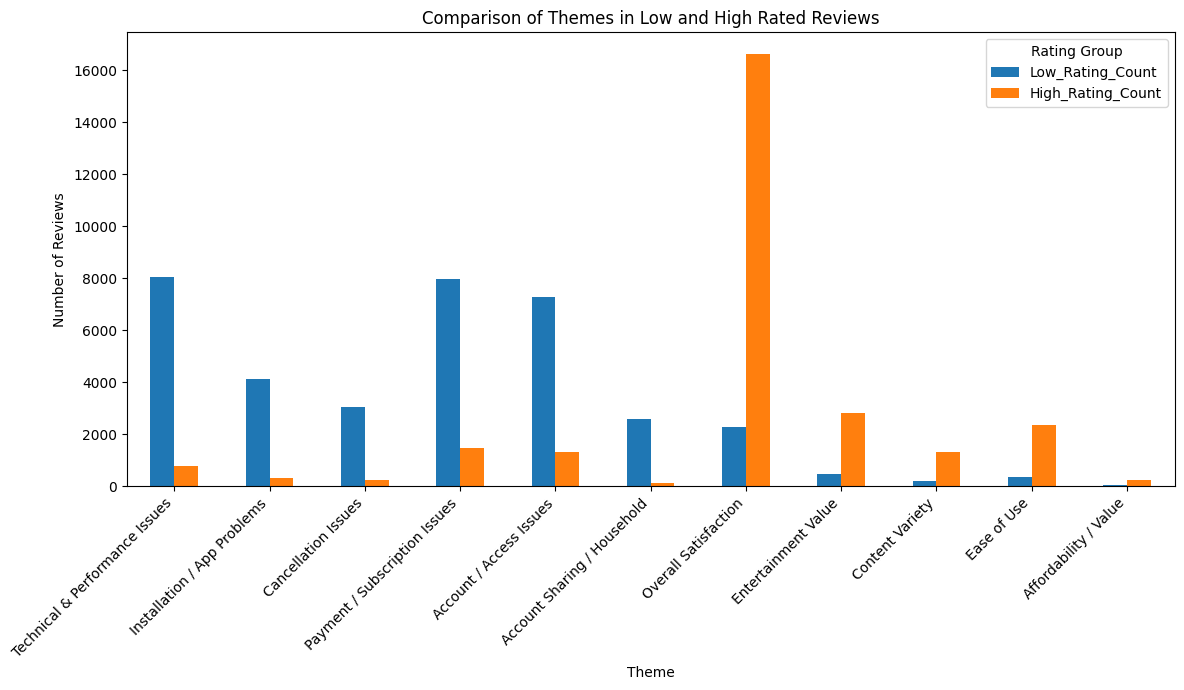

In [ ]:
theme_plot = theme_df.set_index('Theme')[
    ['Low_Rating_Count', 'High_Rating_Count']
]

theme_plot.plot(
    kind='bar',
    figsize=(12, 7)
)

plt.title('Comparison of Themes in Low and High Rated Reviews')
plt.xlabel('Theme')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rating Group')
plt.tight_layout()

plt.show()